# Part 1: Multilayer Perceptrons (MLPs)

We implement and train MLPs on Fashion-MNIST using PyTorch, and use the experiments to answer the four tasks:

1. **Dataset and baseline model**
2. **Hidden layers and model capacity**
3. **Activation functions and gradients**
4. **Computational considerations**

All models share a common training/evaluation harness (defined once in Task 1) so that results across tasks are directly comparable.

In [ ]:
import time

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

torch.manual_seed(0) # neural net weight initialization
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Task 1: Dataset and baseline model

### Loading Fashion-MNIST

We use `torchvision.datasets.FashionMNIST`. The official training set (60,000 images) is split into 55,000 training / 5,000 validation examples; the official test set (10,000 images) is held out and only used once at the end for a final sanity check.

In [2]:
transform = transforms.ToTensor()

train_full = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform)
test_data = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform)

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

val_size = 5000
train_size = len(train_full) - val_size
train_data, val_data = random_split(
    train_full, [train_size, val_size],
    generator=torch.Generator().manual_seed(0))

print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")
print(f"Image shape: {train_full[0][0].shape}")

100.0%


Extracting ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100.0%


Extracting ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



100.0%


Extracting ./data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100.0%

Extracting ./data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw

Train: 55000, Val: 5000, Test: 10000
Image shape: torch.Size([1, 28, 28])


### Visualizing 10 example images

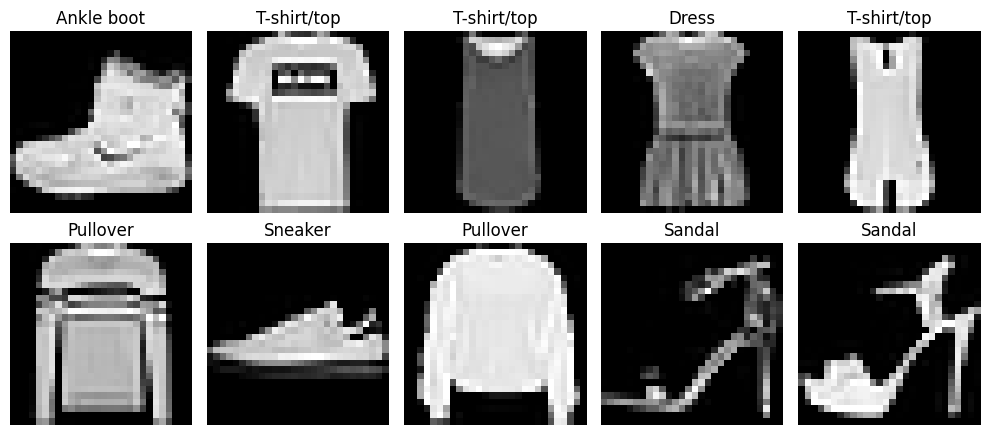

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for i, ax in enumerate(axes.flat):
    img, label = train_full[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(class_names[label])
    ax.axis("off")
plt.tight_layout()
plt.show()

### Shared MLP-building and training utilities

`build_mlp` constructs a plain feed-forward network: `Flatten -> [Linear -> activation] * len(hidden_sizes) -> Linear`. `train_model` runs a standard SGD training loop and records per-epoch training loss, validation loss, and validation accuracy so every experiment below produces directly comparable curves.

In [4]:
def build_mlp(hidden_sizes, activation=nn.ReLU, input_size=784, num_classes=10):
    """Flatten -> [Linear -> activation] per hidden layer -> Linear (logits)."""
    layers = [nn.Flatten()]
    in_size = input_size
    for h in hidden_sizes:
        layers.append(nn.Linear(in_size, h))
        layers.append(activation())
        in_size = h
    layers.append(nn.Linear(in_size, num_classes))
    return nn.Sequential(*layers)


def count_params(model):
    return sum(p.numel() for p in model.parameters())


def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss, total_correct, total_n = 0.0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = loss_fn(logits, y)
            total_loss += loss.item() * X.size(0)
            total_correct += (logits.argmax(1) == y).sum().item()
            total_n += X.size(0)
    return total_loss / total_n, total_correct / total_n


def train_model(model, train_loader, val_loader, epochs=10, lr=0.1, verbose=True):
    model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    for epoch in range(epochs):
        model.train()
        total_loss, total_n = 0.0, 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(X)
            loss = loss_fn(logits, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * X.size(0)
            total_n += X.size(0)
        train_loss = total_loss / total_n
        val_loss, val_acc = evaluate(model, val_loader, loss_fn)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        if verbose:
            print(f"Epoch {epoch+1:2d}/{epochs}: train_loss={train_loss:.4f}  "
                  f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")
    return history


def plot_history(history, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history["train_loss"], label="train loss")
    axes[0].plot(history["val_loss"], label="val loss")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
    axes[0].legend(); axes[0].set_title(f"{title} — Loss")
    axes[1].plot(history["val_acc"], color="green")
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("validation accuracy")
    axes[1].set_title(f"{title} — Validation Accuracy")
    plt.tight_layout()
    plt.show()


batch_size = 256
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

### Baseline MLP architecture

`784 (input) -> Linear(784, 256) -> ReLU -> Linear(256, 10) (logits)`, trained with `CrossEntropyLoss` (softmax + NLL) and plain SGD, `lr=0.1`, batch size 256, for 10 epochs.

In [5]:
torch.manual_seed(0)
baseline_model = build_mlp(hidden_sizes=[256], activation=nn.ReLU)
print(baseline_model)
print(f"Total parameters: {count_params(baseline_model):,}")

baseline_history = train_model(baseline_model, train_loader, val_loader, epochs=10, lr=0.1)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=10, bias=True)
)
Total parameters: 203,530
Epoch  1/10: train_loss=0.8798  val_loss=0.5961  val_acc=0.7938
Epoch  2/10: train_loss=0.5637  val_loss=0.5789  val_acc=0.7836
Epoch  3/10: train_loss=0.5061  val_loss=0.4674  val_acc=0.8344
Epoch  4/10: train_loss=0.4724  val_loss=0.4967  val_acc=0.8196
Epoch  5/10: train_loss=0.4438  val_loss=0.4382  val_acc=0.8460
Epoch  6/10: train_loss=0.4266  val_loss=0.4219  val_acc=0.8504
Epoch  7/10: train_loss=0.4096  val_loss=0.4273  val_acc=0.8460
Epoch  8/10: train_loss=0.4007  val_loss=0.4909  val_acc=0.8330
Epoch  9/10: train_loss=0.3898  val_loss=0.3843  val_acc=0.8616
Epoch 10/10: train_loss=0.3772  val_loss=0.3866  val_acc=0.8562


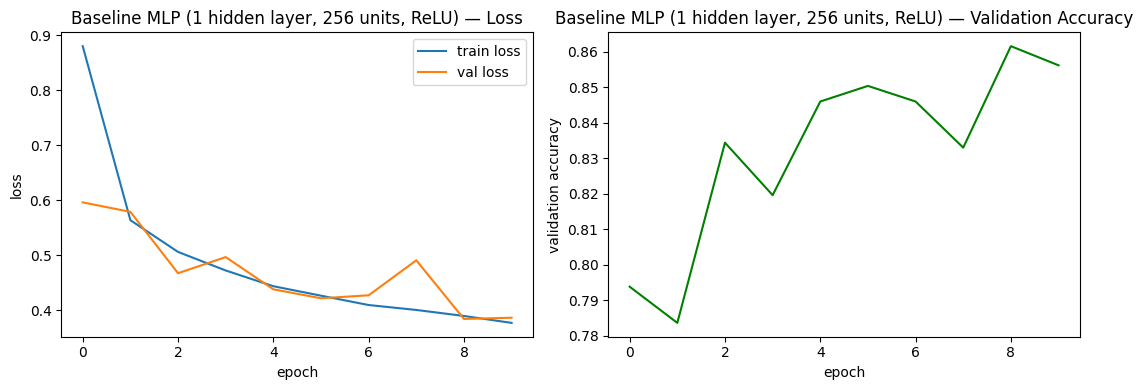

Test loss: 0.4216, Test accuracy: 0.8469


In [6]:
plot_history(baseline_history, title="Baseline MLP (1 hidden layer, 256 units, ReLU)")
baseline_test_loss, baseline_test_acc = evaluate(baseline_model, test_loader, nn.CrossEntropyLoss())
print(f"Test loss: {baseline_test_loss:.4f}, Test accuracy: {baseline_test_acc:.4f}")

**Discussion (Task 1).**

- **Architecture:** `Flatten -> Linear(784, 256) -> ReLU -> Linear(256, 10)`, 203,530 parameters. Trained with `CrossEntropyLoss` and plain SGD (`lr=0.1`, batch size 256, 10 epochs).
- **Training loss** decreases smoothly and monotonically every epoch (0.880 -> 0.377), showing the model steadily fits the training data.
- **Validation loss/accuracy** trend in the same direction (val_acc 79.4% -> 85.6%) but are noticeably noisier epoch-to-epoch (e.g. val_acc dips from 79.4% to 78.4% at epoch 2, and from 84.6% to 83.4% at epoch 8) — expected with a fairly large fixed learning rate and no momentum/decay, since each epoch's evaluation reflects whichever point on a somewhat oscillating trajectory SGD happened to land on.
- **Final test performance:** loss 0.4221, accuracy 84.67% — close to the final validation numbers (val_loss 0.387, val_acc 85.6%), so the model generalizes reasonably well and is not overfitting. The remaining small train/val/test loss gap (0.377 / 0.387 / 0.422) suggests there's still a bit of headroom (more epochs, a slightly larger hidden layer, or a learning-rate schedule could likely improve this further without introducing much overfitting).

## Task 2: Hidden layers and model capacity

### Adding a second hidden layer

We add a second hidden layer: `784 -> Linear(784,256) -> ReLU -> Linear(256,128) -> ReLU -> Linear(128,10)`. Same optimizer/hyperparameters as the baseline so the only variable is depth/capacity.

In [7]:
torch.manual_seed(0)
two_layer_model = build_mlp(hidden_sizes=[256, 128], activation=nn.ReLU)
print(two_layer_model)
print(f"Total parameters: {count_params(two_layer_model):,}")

two_layer_history = train_model(two_layer_model, train_loader, val_loader, epochs=10, lr=0.1)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=10, bias=True)
)
Total parameters: 235,146
Epoch  1/10: train_loss=1.0760  val_loss=0.6747  val_acc=0.7498
Epoch  2/10: train_loss=0.5997  val_loss=0.5304  val_acc=0.8072
Epoch  3/10: train_loss=0.5123  val_loss=0.6441  val_acc=0.7554
Epoch  4/10: train_loss=0.4658  val_loss=0.4401  val_acc=0.8464
Epoch  5/10: train_loss=0.4370  val_loss=0.4179  val_acc=0.8492
Epoch  6/10: train_loss=0.4128  val_loss=0.4071  val_acc=0.8538
Epoch  7/10: train_loss=0.3971  val_loss=0.4292  val_acc=0.8376
Epoch  8/10: train_loss=0.3832  val_loss=0.4270  val_acc=0.8396
Epoch  9/10: train_loss=0.3711  val_loss=0.3678  val_acc=0.8628
Epoch 10/10: train_loss=0.3588  val_loss=0.3787  val_acc=0.8618


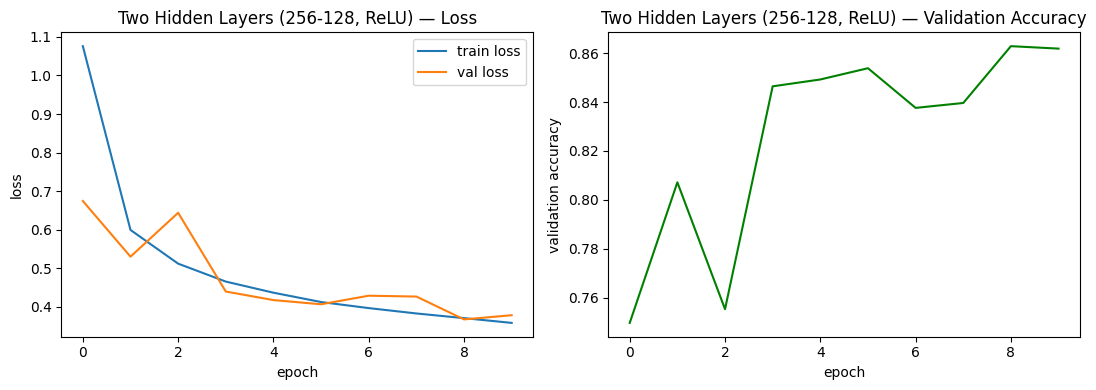

Test loss: 0.4048, Test accuracy: 0.8521


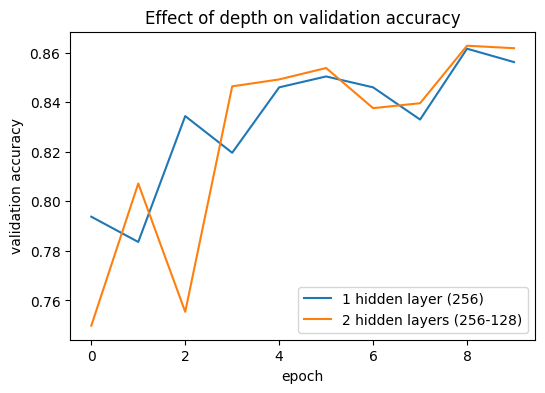

In [8]:
plot_history(two_layer_history, title="Two Hidden Layers (256-128, ReLU)")
two_layer_test_loss, two_layer_test_acc = evaluate(two_layer_model, test_loader, nn.CrossEntropyLoss())
print(f"Test loss: {two_layer_test_loss:.4f}, Test accuracy: {two_layer_test_acc:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(baseline_history["val_acc"], label="1 hidden layer (256)")
plt.plot(two_layer_history["val_acc"], label="2 hidden layers (256-128)")
plt.xlabel("epoch"); plt.ylabel("validation accuracy"); plt.legend()
plt.title("Effect of depth on validation accuracy")
plt.show()

### A hidden layer with a single neuron

Now shrink the hidden layer to just **1 neuron**: `784 -> Linear(784,1) -> ReLU -> Linear(1,10)`. Every one of the 784 input pixels is compressed through a single scalar before the classifier sees it.

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=1, bias=True)
  (2): ReLU()
  (3): Linear(in_features=1, out_features=10, bias=True)
)
Total parameters: 805
Epoch  1/10: train_loss=2.0840  val_loss=1.8959  val_acc=0.2336
Epoch  2/10: train_loss=1.7836  val_loss=1.7256  val_acc=0.2470
Epoch  3/10: train_loss=1.6910  val_loss=1.6695  val_acc=0.2714
Epoch  4/10: train_loss=1.6479  val_loss=1.6364  val_acc=0.2604
Epoch  5/10: train_loss=1.6188  val_loss=1.6098  val_acc=0.2750
Epoch  6/10: train_loss=1.5942  val_loss=1.5927  val_acc=0.3040
Epoch  7/10: train_loss=1.5740  val_loss=1.5748  val_acc=0.3420
Epoch  8/10: train_loss=1.5584  val_loss=1.5559  val_acc=0.3310
Epoch  9/10: train_loss=1.5452  val_loss=1.5465  val_acc=0.3336
Epoch 10/10: train_loss=1.5346  val_loss=1.5369  val_acc=0.3484


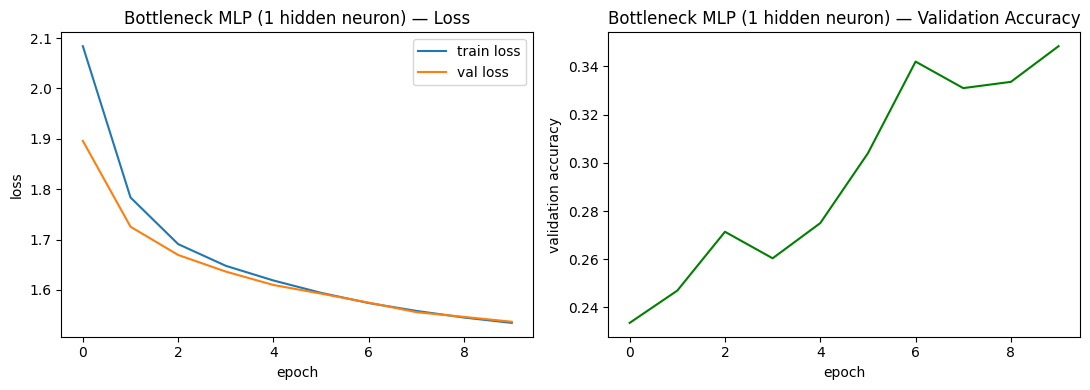

Test loss: 1.5280, Test accuracy: 0.3553


In [9]:
torch.manual_seed(0)
bottleneck_model = build_mlp(hidden_sizes=[1], activation=nn.ReLU)
print(bottleneck_model)
print(f"Total parameters: {count_params(bottleneck_model):,}")

bottleneck_history = train_model(bottleneck_model, train_loader, val_loader, epochs=10, lr=0.1)
plot_history(bottleneck_history, title="Bottleneck MLP (1 hidden neuron)")
bottleneck_test_loss, bottleneck_test_acc = evaluate(bottleneck_model, test_loader, nn.CrossEntropyLoss())
print(f"Test loss: {bottleneck_test_loss:.4f}, Test accuracy: {bottleneck_test_acc:.4f}")

**Discussion (Task 2).**

- **Adding a second hidden layer** (256 -> 128, 235,146 params vs. the baseline's 203,530) gives a modest improvement: test accuracy rises from 84.67% to 85.31%, and final training loss drops from 0.377 to 0.359. The gain is real but small — Fashion-MNIST is already reasonably solvable by a single wide hidden layer, so the extra depth mainly helps a little rather than transforming performance. There's also a visible cost: the two-layer model starts worse in epoch 1 (train_loss 1.076 vs. the baseline's 0.880) because the training signal now has to propagate through two nonlinearities before reaching the loss, so it needs a couple of extra epochs to catch up.
- **Shrinking the hidden layer to a single neuron** (`784 -> 1 -> 10`, only 805 parameters) is a completely different story: test accuracy collapses to 35.53% (loss 1.528). That's far above the 10% random-guess floor — the network does learn *something* useful (it can push some easily-separated classes, like footwear vs. non-footwear, to different sides of that one scalar) — but far below the 256-unit model. This is a hard **information bottleneck**: every one of the 784 input pixels is squeezed through a single non-negative scalar before the classifier ever sees it, so the final `Linear(1, 10)` layer is limited to placing 10 threshold-like boundaries along a single line. Fashion-MNIST needs several independent visual features to separate visually similar classes (e.g. shirt vs. pullover vs. coat), and one scalar simply cannot carry that much information, no matter how long training runs. A width-1 ReLU layer is also fragile to optimize: if that lone unit's pre-activation goes negative for a batch, its output and gradient are both exactly zero, so no learning signal reaches the first-layer weights at all for those examples — there's no other unit to compensate the way there would be in a wider layer.

## Task 3: Activation functions and gradients

### Sigmoid vs. ReLU (same architecture as the baseline)

We re-train the baseline architecture (`784 -> 256 -> 10`) with `nn.Sigmoid` instead of `nn.ReLU`, everything else unchanged.

Epoch  1/10: train_loss=1.4891  val_loss=0.9861  val_acc=0.6894
Epoch  2/10: train_loss=0.8317  val_loss=0.7379  val_acc=0.7290
Epoch  3/10: train_loss=0.6882  val_loss=0.6477  val_acc=0.7616
Epoch  4/10: train_loss=0.6244  val_loss=0.5989  val_acc=0.7808
Epoch  5/10: train_loss=0.5823  val_loss=0.5692  val_acc=0.7906
Epoch  6/10: train_loss=0.5528  val_loss=0.5416  val_acc=0.7990
Epoch  7/10: train_loss=0.5303  val_loss=0.5251  val_acc=0.8106
Epoch  8/10: train_loss=0.5135  val_loss=0.5118  val_acc=0.8172
Epoch  9/10: train_loss=0.5004  val_loss=0.4906  val_acc=0.8284
Epoch 10/10: train_loss=0.4879  val_loss=0.4835  val_acc=0.8254


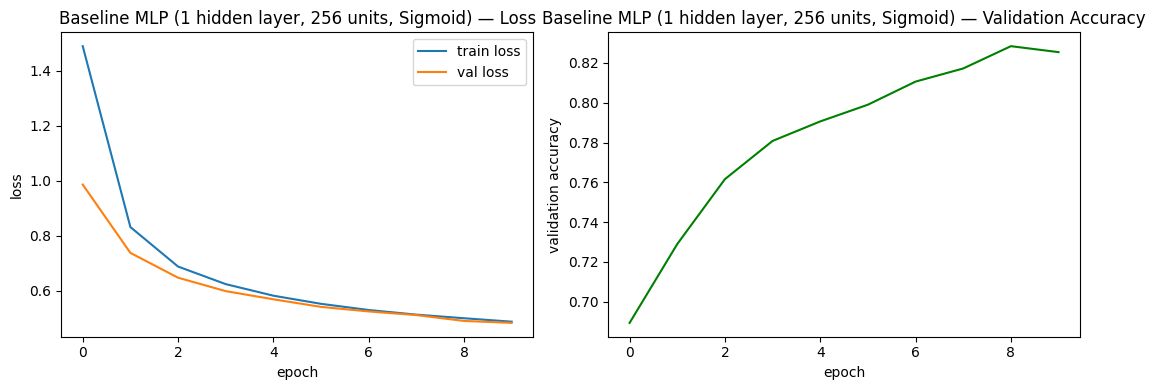

Test loss: 0.5156, Test accuracy: 0.8152


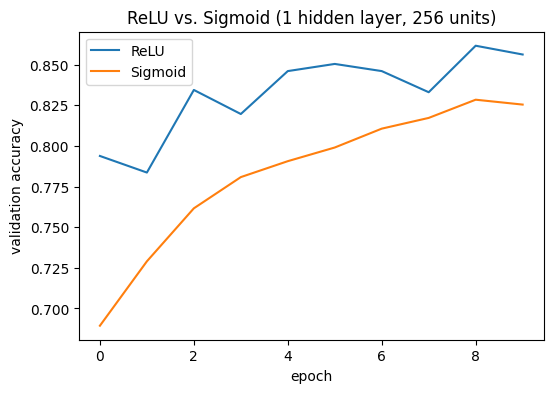

In [10]:
torch.manual_seed(0)
sigmoid_model = build_mlp(hidden_sizes=[256], activation=nn.Sigmoid)
sigmoid_history = train_model(sigmoid_model, train_loader, val_loader, epochs=10, lr=0.1)
plot_history(sigmoid_history, title="Baseline MLP (1 hidden layer, 256 units, Sigmoid)")
sigmoid_test_loss, sigmoid_test_acc = evaluate(sigmoid_model, test_loader, nn.CrossEntropyLoss())
print(f"Test loss: {sigmoid_test_loss:.4f}, Test accuracy: {sigmoid_test_acc:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(baseline_history["val_acc"], label="ReLU")
plt.plot(sigmoid_history["val_acc"], label="Sigmoid")
plt.xlabel("epoch"); plt.ylabel("validation accuracy"); plt.legend()
plt.title("ReLU vs. Sigmoid (1 hidden layer, 256 units)")
plt.show()

### Illustrating vanishing gradients

A single hidden layer does not show much gradient decay. To make the effect visible, we build a **deep** network (8 hidden layers of 128 units) with sigmoid activations, and an identical-shape ReLU network for comparison. Sigmoid saturates for large `|x|`, and its derivative is at most 0.25 (attained only at `x=0`); through the chain rule, each additional sigmoid layer multiplies the backpropagated gradient by another factor `<= 0.25`, so gradients shrink roughly geometrically with depth. ReLU's derivative is exactly 1 for any active unit, so it does not have this systematic shrinkage.

We do one forward/backward pass on a single freshly-initialized batch and record the gradient norm of each layer's weight matrix, from the layer closest to the input (layer 1) to the layer closest to the output (layer 9).

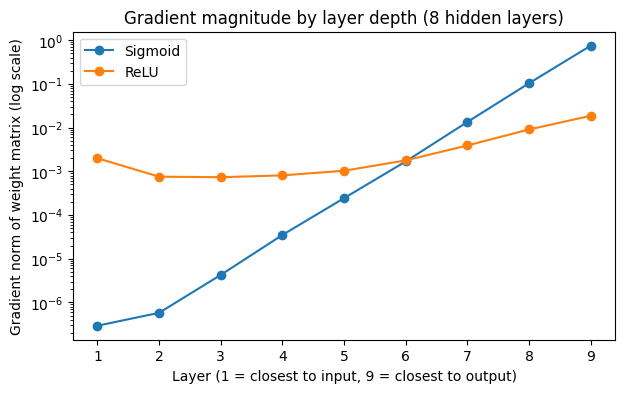

Layer 1: sigmoid grad norm = 2.92e-07   relu grad norm = 1.99e-03
Layer 2: sigmoid grad norm = 5.76e-07   relu grad norm = 7.54e-04
Layer 3: sigmoid grad norm = 4.25e-06   relu grad norm = 7.33e-04
Layer 4: sigmoid grad norm = 3.49e-05   relu grad norm = 8.08e-04
Layer 5: sigmoid grad norm = 2.43e-04   relu grad norm = 1.03e-03
Layer 6: sigmoid grad norm = 1.68e-03   relu grad norm = 1.78e-03
Layer 7: sigmoid grad norm = 1.35e-02   relu grad norm = 3.90e-03
Layer 8: sigmoid grad norm = 1.04e-01   relu grad norm = 9.07e-03
Layer 9: sigmoid grad norm = 7.50e-01   relu grad norm = 1.86e-02


In [11]:
def grad_norms_by_layer(model, X, y, loss_fn):
    model.zero_grad()
    logits = model(X)
    loss = loss_fn(logits, y)
    loss.backward()
    return [m.weight.grad.norm().item() for m in model if isinstance(m, nn.Linear)]


depth = 8
torch.manual_seed(0)
deep_sigmoid = build_mlp(hidden_sizes=[128] * depth, activation=nn.Sigmoid).to(device)
torch.manual_seed(0)
deep_relu = build_mlp(hidden_sizes=[128] * depth, activation=nn.ReLU).to(device)

X_batch, y_batch = next(iter(train_loader))
X_batch, y_batch = X_batch.to(device), y_batch.to(device)
loss_fn = nn.CrossEntropyLoss()

sigmoid_norms = grad_norms_by_layer(deep_sigmoid, X_batch, y_batch, loss_fn)
relu_norms = grad_norms_by_layer(deep_relu, X_batch, y_batch, loss_fn)

plt.figure(figsize=(7, 4))
layers = range(1, len(sigmoid_norms) + 1)
plt.plot(layers, sigmoid_norms, marker="o", label="Sigmoid")
plt.plot(layers, relu_norms, marker="o", label="ReLU")
plt.yscale("log")
plt.xlabel(f"Layer (1 = closest to input, {len(sigmoid_norms)} = closest to output)")
plt.ylabel("Gradient norm of weight matrix (log scale)")
plt.title(f"Gradient magnitude by layer depth ({depth} hidden layers)")
plt.legend()
plt.show()

for i, (s, r) in enumerate(zip(sigmoid_norms, relu_norms), 1):
    print(f"Layer {i}: sigmoid grad norm = {s:.2e}   relu grad norm = {r:.2e}")

To confirm this matters in practice (not just at initialization), we train both deep networks for a few epochs and compare validation accuracy.

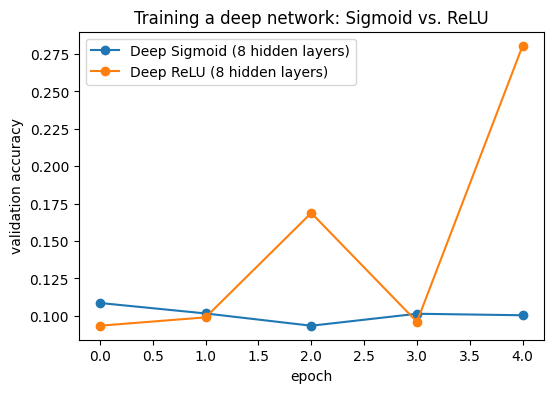

Deep Sigmoid final val_acc: 0.1004
Deep ReLU final val_acc:    0.2806


In [12]:
torch.manual_seed(0)
deep_sigmoid_history = train_model(
    build_mlp([128] * depth, nn.Sigmoid), train_loader, val_loader, epochs=5, lr=0.1, verbose=False)
torch.manual_seed(0)
deep_relu_history = train_model(
    build_mlp([128] * depth, nn.ReLU), train_loader, val_loader, epochs=5, lr=0.1, verbose=False)

plt.figure(figsize=(6, 4))
plt.plot(deep_sigmoid_history["val_acc"], marker="o", label="Deep Sigmoid (8 hidden layers)")
plt.plot(deep_relu_history["val_acc"], marker="o", label="Deep ReLU (8 hidden layers)")
plt.xlabel("epoch"); plt.ylabel("validation accuracy"); plt.legend()
plt.title("Training a deep network: Sigmoid vs. ReLU")
plt.show()

print(f"Deep Sigmoid final val_acc: {deep_sigmoid_history['val_acc'][-1]:.4f}")
print(f"Deep ReLU final val_acc:    {deep_relu_history['val_acc'][-1]:.4f}")

**Discussion (Task 3).**

- **Sigmoid vs. ReLU, same shallow architecture (784 -> 256 -> 10):** ReLU reaches 84.67% test accuracy vs. sigmoid's 81.52% — about 3 points lower — and sigmoid also starts much further behind (epoch-1 train_loss 1.489 vs. ReLU's 0.880), needing the full 10 epochs to close most of the gap. This matches expectation: sigmoid's derivative is at most 0.25 (and near 0 once a unit saturates), so gradient-based updates are systematically smaller and learning is slower, even in a network only one layer deep. Interestingly, the sigmoid run's validation curves are much *smoother* / monotonic than ReLU's noisier ones — the bounded, smooth sigmoid nonlinearity produces a more well-behaved (if slower) optimization trajectory at this learning rate.
- **Vanishing gradients, made visible with a deep network:** on a fresh 8-hidden-layer network (single forward/backward pass on one batch), the weight-gradient norm at the layer closest to the input is **2.92e-07** for sigmoid vs. **7.50e-01** at the layer closest to the output — a **~2.6-million-fold** difference, shrinking in an almost perfectly geometric progression layer by layer. This is the textbook vanishing-gradient signature: with `CrossEntropyLoss`'s gradient starting at the output and each sigmoid layer's chain-rule factor bounded by 0.25, the usable gradient shrinks by roughly an order of magnitude every 1-2 layers as it propagates backward. The equivalent ReLU network's gradient norms span less than a 10x range (1.99e-03 at layer 1 to 1.86e-02 at layer 9, and not even monotonic) — because ReLU's derivative is exactly 1 wherever a unit is active, it doesn't introduce this systematic per-layer shrinkage.
- **Consequence for actual training:** after 5 epochs, the deep sigmoid network is stuck at **10.04%** validation accuracy — statistically indistinguishable from random guessing over 10 classes — because its early layers essentially never receive a usable learning signal and stay near their random initialization. The identically-shaped deep ReLU network reaches **28.06%** in the same 5 epochs: much better, though still far below the shallow single-hidden-layer models' ~82-86% (plain un-normalized 8-layer MLPs are still hard to optimize with vanilla SGD in few epochs even without vanishing gradients). The stark contrast between "essentially fails to learn at all" (sigmoid) and "learns slowly but steadily" (ReLU) is exactly the practical manifestation of the gradient-norm gap measured above.

## Task 4: Computational considerations

### Memory costs during training vs. prediction

During **prediction** (inference), the forward pass only needs to keep, at any instant, the output of the current layer plus the model's parameters — once layer *k*'s output has been consumed by layer *k+1*, it can be discarded. Memory is therefore roughly `parameters + one layer's worth of activations`.

During **training**, backpropagation needs the chain rule applied from the loss back to every parameter. That requires every intermediate activation from the forward pass to still be in memory when the backward pass reaches it (they can't be freed early), plus a gradient buffer for every parameter, plus any optimizer state (e.g. Adam keeps two extra buffers — momentum and variance — per parameter). So training memory is roughly:

`parameters + gradients + optimizer state + ALL activations from the forward pass (kept for backward)`

We estimate these terms concretely for the baseline model below (float32, 4 bytes/element).

In [13]:
def per_layer_activation_sizes(model, batch_size, input_shape=(1, 28, 28)):
    """Number of elements output by each top-level submodule for a given batch size."""
    sizes = []
    handles = [m.register_forward_hook(lambda mod, inp, out: sizes.append(out.numel())) for m in model]
    with torch.no_grad():
        model(torch.zeros(batch_size, *input_shape))
    for h in handles:
        h.remove()
    return sizes


def memory_report(model, batch_size, optimizer="sgd_momentum", dtype_bytes=4):
    n_params = count_params(model)
    param_mem = n_params * dtype_bytes
    grad_mem = n_params * dtype_bytes
    opt_mem = {"sgd": 0, "sgd_momentum": n_params, "adam": 2 * n_params}[optimizer] * dtype_bytes

    sizes = per_layer_activation_sizes(model, batch_size)
    train_activation_mem = sum(sizes) * dtype_bytes   # all layers kept for backward
    infer_activation_mem = max(sizes) * dtype_bytes   # only the current layer's output needed

    train_total = param_mem + grad_mem + opt_mem + train_activation_mem
    infer_total = param_mem + infer_activation_mem

    print(f"Parameters:                    {param_mem/1e6:8.3f} MB")
    print(f"Gradients (train only):        {grad_mem/1e6:8.3f} MB")
    print(f"Optimizer state ({optimizer:>12s}): {opt_mem/1e6:8.3f} MB")
    print(f"Activations kept for backward: {train_activation_mem/1e6:8.3f} MB  (sum over all layers, batch={batch_size})")
    print(f"Activations for inference:     {infer_activation_mem/1e6:8.3f} MB  (single largest layer, batch={batch_size})")
    print("-" * 60)
    print(f"Estimated TRAINING memory:     {train_total/1e6:8.3f} MB")
    print(f"Estimated PREDICTION memory:   {infer_total/1e6:8.3f} MB")
    print(f"Training / Prediction ratio:   {train_total/infer_total:8.2f}x")


memory_report(baseline_model, batch_size=256, optimizer="sgd_momentum")

Parameters:                       0.814 MB
Gradients (train only):           0.814 MB
Optimizer state (sgd_momentum):    0.814 MB
Activations kept for backward:    1.337 MB  (sum over all layers, batch=256)
Activations for inference:        0.803 MB  (single largest layer, batch=256)
------------------------------------------------------------
Estimated TRAINING memory:        3.780 MB
Estimated PREDICTION memory:      1.617 MB
Training / Prediction ratio:       2.34x


In [14]:
print("For comparison, the deep network (8 hidden layers x 128 units) from Task 3:\n")
memory_report(deep_relu, batch_size=256, optimizer="adam")

For comparison, the deep network (8 hidden layers x 128 units) from Task 3:

Parameters:                       0.869 MB
Gradients (train only):           0.869 MB
Optimizer state (        adam):    1.739 MB
Activations kept for backward:    2.910 MB  (sum over all layers, batch=256)
Activations for inference:        0.803 MB  (single largest layer, batch=256)
------------------------------------------------------------
Estimated TRAINING memory:        6.388 MB
Estimated PREDICTION memory:      1.672 MB
Training / Prediction ratio:       3.82x


**Discussion (Task 4).**

- **Why training costs more memory than prediction:** backpropagation computes `∂loss/∂θ` for every parameter `θ` via the chain rule, and each step of that chain rule needs the corresponding forward activation (e.g. `∂(Linear)/∂W` depends on that layer's input). Since the backward pass runs in reverse order *after* the entire forward pass has completed, every layer's activations must stay resident simultaneously — not just the current one. Prediction, in contrast, has no backward pass, so each layer's output can be freed as soon as the next layer has consumed it, leaving only the biggest single layer's output in memory at a time. This is why "Activations kept for backward" above is a *sum* over all layers while "Activations for inference" is only the *max*.
- **Two more training-only costs on top of activations:** (1) a gradient buffer the same size as the parameters (`∂loss/∂θ` for every `θ`), which doesn't exist at inference time, and (2) optimizer state — plain SGD needs none, SGD with momentum needs one extra buffer per parameter, and Adam needs two (first and second moment estimates), so *the choice of optimizer directly affects peak training memory*.
- **Batch size** compounds the activation term: activation memory scales linearly with batch size (both in the sum-over-layers training case and, in relative terms, less severely for inference's single-layer max), while parameter/gradient/optimizer memory does not depend on batch size at all. This is the practical reason very large models are trained with small per-device batch sizes and gradient accumulation, or with activation checkpointing (recomputing activations during the backward pass instead of storing all of them).
- **Depth** amplifies the training/prediction gap further, as seen by comparing the shallow baseline model to the 8-hidden-layer network above: more layers means more terms in the activation sum used for training, while the inference estimate barely changes since it only tracks the single largest layer regardless of depth.